# 랜덤행렬이론(RMT) 공분산 필터링과 포트폴리오 최적화 — 수정·확장판

원자료: Steve 98654, *PyData Talk — Correlation filtering* (`pydata_talk.ipynb`)

**이 실습에서 확인할 질문**

1. 표본 상관행렬의 고유값 가운데 어느 것이 **신호**이고 어느 것이 **잡음**인가? (Marchenko–Pastur 법칙)
2. 잡음 고유값을 평탄화(eigenvalue clipping)하면 Markowitz 최적화 결과가 얼마나 바뀌는가? (in-sample)
3. **다음 달에 실현된 위험**으로 평가하면 표본·RMT·Ledoit–Wolf 공분산 중 무엇이 나은가? (out-of-sample, 원본에 없던 부분)

**원본 대비 수정 사항**

| 원본 | 문제 | 수정 |
|---|---|---|
| `la.eig` 후 정렬 없이 자르기 | 고유값 순서가 보장되지 않아 엉뚱한 고유값을 평탄화 | `la.eigh` + 내림차순 정렬 |
| 재구성 행렬에 `abs()` | 음의 상관이 양수로 뒤집힘 | `eigh`는 실수·대칭이므로 불필요, 제거 |
| `nearcorr` 투영 | 필요 이상으로 복잡 | 평탄화 후 행렬은 이미 양정치 → 대각 정규화 $D^{-1/2}CD^{-1/2}$로 충분 |
| 투자선 위험을 모두 `ocov`로 계산 | 필터 공분산의 해도 원본 공분산으로 평가 | 각 해를 두 공분산 모두로 평가해 비교 |
| MP 상한 $\lambda_+$에 $\sigma^2=1$ | 시장 팩터가 분산을 흡수하므로 잡음 분산이 과대 | $\sigma^2 = 1-\lambda_1/N$ 보정(Laloux et al., 2000) |
| `tsplot`, `normed`, `as_matrix`, `sum_entries` | 현행 라이브러리에서 오류 | 현행 API로 교체 |
| in-sample 비교만 | 필터의 실제 가치(예측 위험 정확도)를 검증 못 함 | 롤링 out-of-sample 백테스트 추가 |

데이터는 `yfinance`로 직접 내려받습니다. 종목 목록은 Wikipedia 현행 S&P 500 목록을 쓰고, 접속이 안 되면 같은 폴더의 `SandP500_wiki.csv`를 씁니다.

## 0. 환경 설정

In [1]:
# Colab이면 주석 해제
# !pip install -q yfinance cvxpy scikit-learn lxml

import io, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import cvxpy as cp
from sklearn.covariance import LedoitWolf

warnings.filterwarnings("ignore")

# 한글 폰트: 설치된 한글 폰트를 찾고, Colab에 없으면 나눔고딕을 자동 설치
import os, subprocess
from matplotlib import font_manager as fm
KR_FONTS = ["NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR", "Noto Sans CJK JP", "Noto Sans KR"]
def _pick_kr_font():
    names = {f.name for f in fm.fontManager.ttflist}
    return next((c for c in KR_FONTS if c in names), None)
if _pick_kr_font() is None and os.path.exists("/content"):          # Colab
    subprocess.run("apt-get -qq install -y fonts-nanum", shell=True, capture_output=True)
    fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
if _pick_kr_font():
    plt.rcParams["font.family"] = _pick_kr_font()
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
np.random.seed(42)

START, END = "2016-01-01", "2025-12-31"   # 분석 기간
MAX_MISSING = 0.02                         # 결측 2% 초과 종목 제외

## 1. 데이터 — S&P 500 일별 수정종가

현행 구성종목으로 과거 10년을 보므로 **생존 편향(survivorship bias)**이 있습니다. 공분산 추정 방법을 *상대 비교*하는 목적에는 큰 문제가 없지만, 수익률 수준을 해석할 때는 주의합니다.

In [2]:
def load_sp500_list():
    try:
        import requests
        html = requests.get("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
                            headers={"User-Agent": "Mozilla/5.0"}, timeout=15).text
        t = pd.read_html(io.StringIO(html))[0]
        t = t.rename(columns={"Symbol": "Ticker", "GICS Sector": "Sector"})
        print("Wikipedia 현행 목록 사용")
    except Exception as e:
        t = pd.read_csv("SandP500_wiki.csv").rename(
            columns={"Ticker symbol": "Ticker", "GICS Sector": "Sector"})
        print("로컬 SandP500_wiki.csv 사용 (Wikipedia 접속 실패)")
    t["Ticker"] = t["Ticker"].str.replace(".", "-", regex=False)   # BRK.B → BRK-B
    return t[["Ticker", "Sector"]].drop_duplicates("Ticker")

universe = load_sp500_list()
print(len(universe), "종목")
universe.head()

로컬 SandP500_wiki.csv 사용 (Wikipedia 접속 실패)
505 종목


,Ticker,Sector
0,MMM,Industrials
1,ABT,Health Care
2,ABBV,Health Care
3,ACN,Information Technology
4,ACE,Financials


In [3]:
px = yf.download(universe["Ticker"].tolist(), start=START, end=END,
                 auto_adjust=True, progress=False, threads=True)["Close"]

px = px.loc[:, px.isna().mean() <= MAX_MISSING]      # 결측 많은 종목(상장 늦음·폐지) 제외
px = px.ffill().dropna()
ret = px.pct_change().dropna()
sector = universe.set_index("Ticker")["Sector"].reindex(ret.columns)

T_all, N = ret.shape
print(f"기간 {ret.index[0].date()} ~ {ret.index[-1].date()} | T={T_all}일, N={N}종목")

기간 2016-01-05 ~ 2025-12-30 | T=2512일, N=364종목


## 2. 잡음의 기준선 — Marchenko–Pastur 법칙

$T\times N$ 행렬의 원소가 서로 독립이고 분산이 $\sigma^2$이면, $T,N\to\infty$, $q=T/N$ 고정일 때 표본 상관행렬 고유값의 밀도는

$$
f(\lambda)=\frac{q}{2\pi\sigma^2\lambda}\sqrt{(\lambda_+-\lambda)(\lambda-\lambda_-)},\qquad
\lambda_\pm=\sigma^2\left(1\pm\sqrt{1/q}\right)^2
$$

입니다. **상관이 전혀 없어도** 고유값은 1 하나로 모이지 않고 $[\lambda_-,\lambda_+]$에 퍼집니다. 이 구간 안의 고유값은 표본 잡음과 구별되지 않습니다.

먼저 독립 t분포(자유도 5, 두꺼운 꼬리) 수익률로 이 법칙이 맞는지 확인합니다.

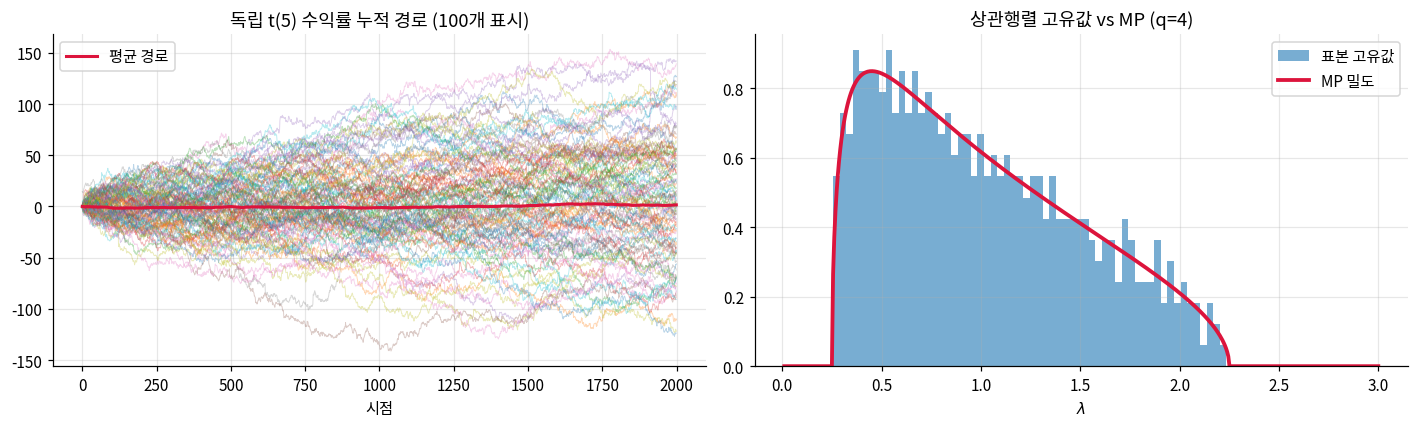

λ± 이론: [0.25 2.25] | 표본 min/max: 0.257 2.235


In [4]:
def mp_pdf(lam, q, sigma2=1.0):
    lp, lm = sigma2 * (1 + np.sqrt(1/q))**2, sigma2 * (1 - np.sqrt(1/q))**2
    out = np.zeros_like(lam)
    m = (lam > lm) & (lam < lp)
    out[m] = q / (2*np.pi*sigma2*lam[m]) * np.sqrt((lp-lam[m]) * (lam[m]-lm))
    return out

def mp_bounds(q, sigma2=1.0):
    return sigma2 * (1 - np.sqrt(1/q))**2, sigma2 * (1 + np.sqrt(1/q))**2

T_sim, N_sim = 2000, 500
X = np.random.standard_t(df=5, size=(T_sim, N_sim))
ev_sim = np.linalg.eigvalsh(np.corrcoef(X, rowvar=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(X.cumsum(0)[:, :100], lw=0.6, alpha=0.3)
ax[0].plot(X.cumsum(0).mean(1), c="crimson", lw=2, label="평균 경로")
ax[0].set(title="독립 t(5) 수익률 누적 경로 (100개 표시)", xlabel="시점"); ax[0].legend()

grid = np.linspace(0.01, 3, 500)
ax[1].hist(ev_sim, bins=60, density=True, alpha=0.6, label="표본 고유값")
ax[1].plot(grid, mp_pdf(grid, T_sim/N_sim), c="crimson", lw=2.5, label="MP 밀도")
ax[1].set(title=f"상관행렬 고유값 vs MP (q={T_sim/N_sim:.0f})", xlabel=r"$\lambda$"); ax[1].legend()
plt.tight_layout(); plt.show()
print("λ± 이론:", np.round(mp_bounds(T_sim/N_sim), 3), "| 표본 min/max:", ev_sim.min().round(3), ev_sim.max().round(3))

두꺼운 꼬리 분포여도 분산이 유한하면 MP 밀도가 잘 맞습니다.

## 3. 실제 S&P 500 상관행렬의 고유값

in-sample 구간은 앞 5년(2016–2020)으로 잡습니다. 실제 주식에는 **시장 팩터**가 있어 가장 큰 고유값 $\lambda_1$이 분산의 상당 부분을 가져갑니다. 그만큼 잡음에 남는 분산이 줄어들므로 MP 분포의 $\sigma^2$를 $1-\lambda_1/N$으로 보정합니다.

In [5]:
IS_END = "2020-12-31"
R_is = ret.loc[:IS_END]
T_is = len(R_is); q_is = T_is / N

corr_is = R_is.corr().values
evals, evecs = np.linalg.eigh(corr_is)
order = np.argsort(evals)[::-1]                # 내림차순 정렬 (원본의 버그 수정)
evals, evecs = evals[order], evecs[:, order]

sigma2 = 1 - evals[0] / N
lam_minus, lam_plus = mp_bounds(q_is, sigma2)
k_signal = int((evals > lam_plus).sum())

print(f"T={T_is}, N={N}, q={q_is:.2f}")
print(f"λ1 = {evals[0]:.1f}  → 전체 분산의 {evals[0]/N:.1%} (시장 팩터)")
print(f"보정 σ² = {sigma2:.3f}, λ+ = {lam_plus:.3f}")
print(f"λ+를 넘는 신호 고유값: {k_signal}개 / {N}개 → 설명 분산 {evals[:k_signal].sum()/N:.1%}")
print("상위 10개:", np.round(evals[:10], 2))

T=1258, N=364, q=3.46
λ1 = 152.6  → 전체 분산의 41.9% (시장 팩터)
보정 σ² = 0.581, λ+ = 1.373
λ+를 넘는 신호 고유값: 24개 / 364개 → 설명 분산 67.7%
상위 10개: [152.64  21.25  13.21   7.18   5.48   4.8    4.11   3.89   3.49   3.02]


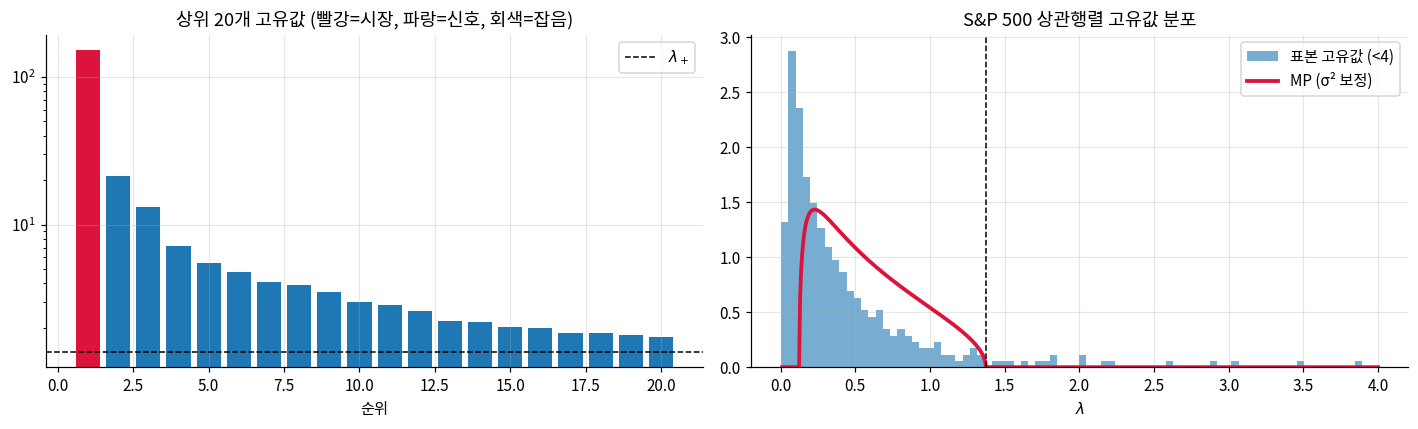

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(range(1, 21), evals[:20], color=["crimson"] + ["tab:blue"]*(k_signal-1) + ["grey"]*(20-k_signal))
ax[0].axhline(lam_plus, ls="--", c="k", lw=1, label=r"$\lambda_+$")
ax[0].set(yscale="log", title="상위 20개 고유값 (빨강=시장, 파랑=신호, 회색=잡음)", xlabel="순위"); ax[0].legend()

grid = np.linspace(0.01, 4, 600)
ax[1].hist(evals[evals < 4], bins=80, density=True, alpha=0.6, label="표본 고유값 (<4)")
ax[1].plot(grid, mp_pdf(grid, q_is, sigma2), c="crimson", lw=2.5, label="MP (σ² 보정)")
ax[1].axvline(lam_plus, ls="--", c="k", lw=1)
ax[1].set(title="S&P 500 상관행렬 고유값 분포", xlabel=r"$\lambda$"); ax[1].legend()
plt.tight_layout(); plt.show()

### 신호 고유벡터는 무엇을 담고 있나

고유벡터의 성분을 섹터별로 더해 보면 신호 고유값이 경제적으로 해석되는지 확인할 수 있습니다. 1번은 모든 종목이 같은 부호로 실린 **시장 팩터**, 2번 이후는 **섹터 대비**(예: 에너지·유틸리티 vs 기술)로 나타나는 경우가 많습니다.

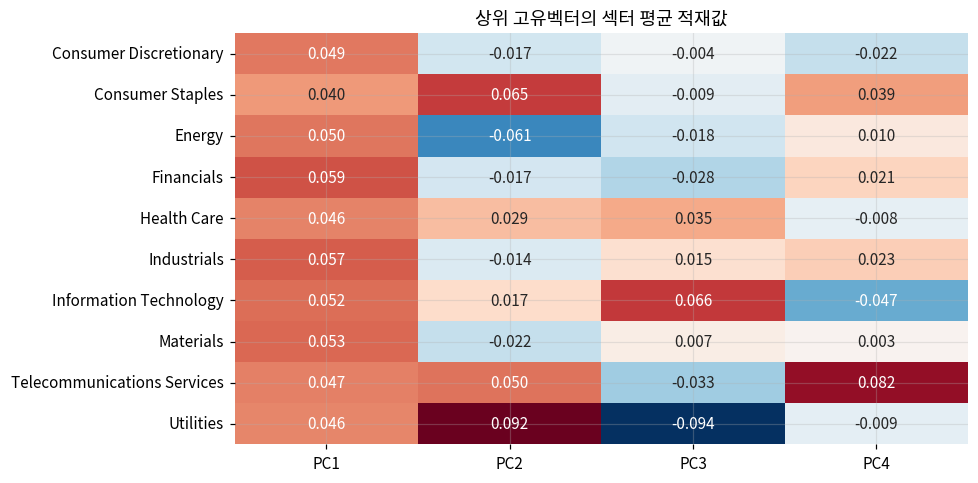

In [7]:
load = pd.DataFrame(evecs[:, :4] * np.sign(evecs[:, :4].sum(0)), index=R_is.columns,
                    columns=[f"PC{i}" for i in range(1, 5)])
sec_load = load.groupby(sector.values).mean()

plt.figure(figsize=(9, 4.5))
sns.heatmap(sec_load, cmap="RdBu_r", center=0, annot=True, fmt=".3f", cbar=False)
plt.title("상위 고유벡터의 섹터 평균 적재값"); plt.ylabel(""); plt.tight_layout(); plt.show()

## 4. RMT 필터 — 고유값 평탄화(eigenvalue clipping)

1. $\lambda_i>\lambda_+$ 인 고유값(신호)은 그대로 둡니다.
2. 나머지(잡음)는 평균 $\bar\lambda$로 바꿉니다. 대각합 $\sum\lambda_i=N$이 유지됩니다.
3. $\tilde C = E\,\tilde\Lambda\,E^\top$ 로 재구성합니다. $\bar\lambda>0$ 이므로 $\tilde C$는 자동으로 양정치입니다.
4. 대각이 정확히 1이 되도록 $\hat C = D^{-1/2}\tilde C D^{-1/2}$, $D=\mathrm{diag}(\tilde C)$ 로 정규화합니다.
5. 공분산 복원: $\hat\Sigma = \mathrm{diag}(\sigma)\,\hat C\,\mathrm{diag}(\sigma)$

원본은 4단계에서 Higham의 nearest correlation 최적화를 썼지만, 평탄화 결과가 이미 양정치이므로 대각 정규화로 충분합니다.

In [8]:
def rmt_clip_corr(C, T, adjust_sigma=True):
    '''Eigenvalue clipping (Laloux–Bouchaud–Potters). 반환: (필터 상관행렬, 신호 고유값 개수)'''
    N = C.shape[0]
    lam, vec = np.linalg.eigh(C)
    idx = np.argsort(lam)[::-1]; lam, vec = lam[idx], vec[:, idx]
    s2 = 1 - lam[0] / N if adjust_sigma else 1.0
    lp = s2 * (1 + np.sqrt(N / T))**2
    k = max(int((lam > lp).sum()), 1)
    lam_f = lam.copy(); lam_f[k:] = lam[k:].mean()
    Cf = (vec * lam_f) @ vec.T
    d = np.sqrt(np.diag(Cf))
    return Cf / np.outer(d, d), k

def cov_sample(R):
    return np.cov(R, rowvar=False)

def cov_rmt(R):
    sd = R.std(0, ddof=1)
    Cf, _ = rmt_clip_corr(np.corrcoef(R, rowvar=False), len(R))
    return Cf * np.outer(sd, sd)

def cov_lw(R):
    return LedoitWolf().fit(R).covariance_

Rv = R_is.values
S_raw, S_rmt, S_lw = cov_sample(Rv), cov_rmt(Rv), cov_lw(Rv)
C_rmt, k = rmt_clip_corr(corr_is, T_is)

for name, S in [("Sample", S_raw), ("RMT", S_rmt), ("Ledoit-Wolf", S_lw)]:
    e = np.linalg.eigvalsh(S)
    print(f"{name:12s} 조건수 = {e.max()/e.min():>12,.0f}")

Sample       조건수 =       82,916
RMT          조건수 =        1,435
Ledoit-Wolf  조건수 =        4,304


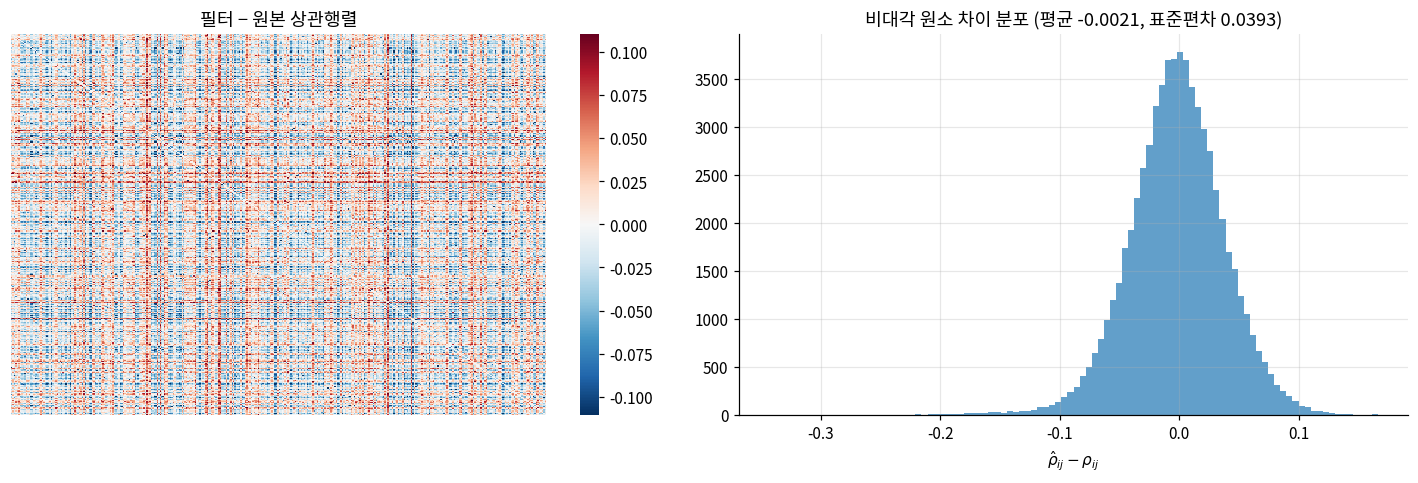

In [9]:
diff = C_rmt - corr_is
off = diff[np.triu_indices(N, 1)]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
lim = np.percentile(np.abs(off), 99)
sns.heatmap(diff, cmap="RdBu_r", center=0, vmin=-lim, vmax=lim, ax=ax[0],
            xticklabels=False, yticklabels=False)
ax[0].set_title("필터 − 원본 상관행렬")
ax[1].hist(off, bins=100, color="tab:blue", alpha=0.7)
ax[1].set(title=f"비대각 원소 차이 분포 (평균 {off.mean():+.4f}, 표준편차 {off.std():.4f})",
          xlabel=r"$\hat\rho_{ij}-\rho_{ij}$")
plt.tight_layout(); plt.show()

개별 상관계수의 변화는 작지만, 최적화는 공분산의 **역행렬**을 쓰기 때문에 작은 고유값이 바뀐 효과가 크게 증폭됩니다. 위의 조건수 차이가 그 규모를 보여줍니다.

## 5. In-sample 효율적 투자선 (원본 재현 + 수정)

원본과 같은 목적함수를 CVXPY로 풉니다.

$$
\hat w(\lambda)=\arg\min_w\ w^\top\Sigma w-\lambda\,\hat\mu^\top w+\gamma\lVert w\rVert_1,\qquad \textstyle\sum_i w_i=1
$$

- $\lambda$: 수익 선호 강도. 바꿔 가며 풀면 투자선을 따라 이동합니다.
- $\gamma\lVert w\rVert_1$: 공매도를 허용하되 총 레버리지와 종목 수를 억제합니다. 원본 설정대로 $\gamma=0.003$을 씁니다.

**원본의 버그 수정:** 각 해의 위험을 *두 공분산 모두*로 평가합니다. "필터 공분산으로 구한 해를 필터 공분산으로 평가한 위험"은 모형이 스스로 **예상한** 위험이고, 원본 공분산으로 평가한 값은 표본 기준 위험입니다. 진짜 판정은 6절의 out-of-sample에서 합니다.

In [10]:
mu_is = Rv.mean(0)
GAMMA = 0.003
lams = np.linspace(-2, 2, 41)

def frontier(S, mu, gamma, lams):
    n = len(mu)
    w = cp.Variable(n); lam = cp.Parameter()
    S_psd = cp.psd_wrap((S + S.T) / 2)
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, S_psd) - lam * mu @ w + gamma * cp.norm1(w)),
                      [cp.sum(w) == 1])
    W = []
    for l in lams:
        lam.value = l; prob.solve(solver=cp.CLARABEL)
        W.append(w.value.copy())
    return np.array(W)

t0 = time.time()
W_raw = frontier(S_raw, mu_is, GAMMA, lams)
W_rmt = frontier(S_rmt, mu_is, GAMMA, lams)
print(f"풀이 시간 {time.time()-t0:.1f}s")

ann_vol = lambda W, S: np.sqrt(252 * np.einsum("ki,ij,kj->k", W, S, W))
ann_ret = lambda W: 252 * W @ mu_is

풀이 시간 9.5s


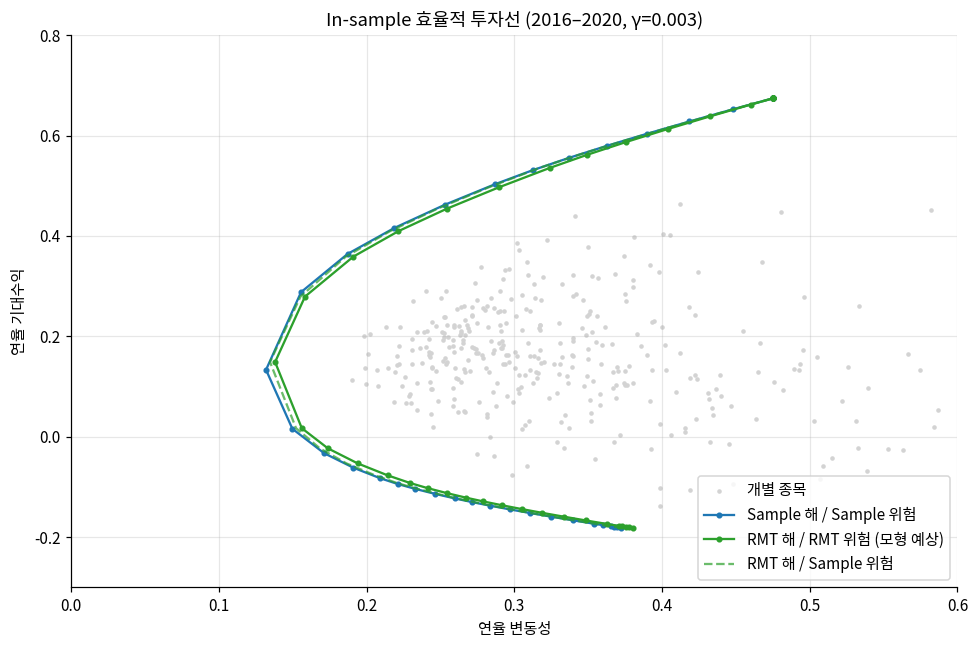

평균 보유 종목 수  Sample: 6.5 | RMT: 6.5
평균 총 노출 Σ|w|  Sample: 1.0 | RMT: 1.0


In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
sd_i, mu_i = np.sqrt(252) * Rv.std(0), 252 * mu_is
ax.scatter(sd_i, mu_i, s=4, c="lightgrey", label="개별 종목")
ax.plot(ann_vol(W_raw, S_raw), ann_ret(W_raw), "-o", ms=3, c="tab:blue", label="Sample 해 / Sample 위험")
ax.plot(ann_vol(W_rmt, S_rmt), ann_ret(W_rmt), "-o", ms=3, c="tab:green", label="RMT 해 / RMT 위험 (모형 예상)")
ax.plot(ann_vol(W_rmt, S_raw), ann_ret(W_rmt), "--", c="tab:green", alpha=0.7, label="RMT 해 / Sample 위험")
ax.set(xlim=(0, 0.6), ylim=(-0.3, 0.8), xlabel="연율 변동성", ylabel="연율 기대수익",
       title=f"In-sample 효율적 투자선 (2016–2020, γ={GAMMA})")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

nz = lambda W: (np.abs(W) > 1e-4).sum(1)
print("평균 보유 종목 수  Sample:", nz(W_raw).mean().round(1), "| RMT:", nz(W_rmt).mean().round(1))
print("평균 총 노출 Σ|w|  Sample:", np.abs(W_raw).sum(1).mean().round(2), "| RMT:", np.abs(W_rmt).sum(1).mean().round(2))

**읽는 법**

- in-sample에서는 표본 공분산이 **자기 데이터에 최적화**되어 있으므로 Sample 투자선이 가장 좋아 보이는 것이 당연합니다. RMT 해를 Sample 위험으로 평가한 점선은 항상 Sample 투자선의 오른쪽에 있습니다.
- 원본이 "두 선이 거의 같다"고 한 것은 L1 페널티가 해를 강하게 규제하고 있기 때문이기도 합니다. γ를 0.0003으로 줄여 다시 돌려 보면 차이가 커집니다.
- 따라서 in-sample 투자선만 보고 필터의 가치를 판단할 수 없습니다. → 6절

## 6. Out-of-sample 검증 — 롤링 최소분산 포트폴리오

기대수익 추정 오차를 배제하고 **공분산 추정의 질만** 비교하기 위해 전역 최소분산(GMV) 포트폴리오를 씁니다.

$$
w_{\text{GMV}}=\frac{\Sigma^{-1}\mathbf 1}{\mathbf 1^\top\Sigma^{-1}\mathbf 1}\quad(\text{공매도 허용}),\qquad
\min_w w^\top\Sigma w\ \ \text{s.t. } \textstyle\sum w_i=1,\ w\ge 0\quad(\text{롱온리})
$$

**설계**

- 추정 창 $L=504$일(2년) → $q=L/N\approx 1$. 표본 공분산이 거의 특이행렬에 가까운, 실무에서 흔한 상황입니다.
- 21거래일마다 재추정하고 다음 21일간 보유합니다.
- 비교 대상: Sample · RMT · Ledoit–Wolf · 1/N(동일가중)

**평가 지표**

| 지표 | 의미 |
|---|---|
| 실현 변동성 | 낮을수록 좋음 (GMV의 목표) |
| 편향비 = 실현 변동성 / 예상 변동성 | 1에 가까울수록 위험 예측이 정직함. 1보다 크면 위험을 과소평가 |
| 회전율 | 재조정 때 $\tfrac12\sum|w_t-w_{t-1}|$ 평균 |
| 총 노출 $\sum|w_i|$ | 공매도 허용 시 레버리지 크기 |

In [12]:
L, H = 504, 21

def gmv_closed(S):
    x = np.linalg.solve(S, np.ones(len(S)))
    return x / x.sum()

def gmv_longonly(S):
    w = cp.Variable(len(S))
    cp.Problem(cp.Minimize(cp.quad_form(w, cp.psd_wrap((S+S.T)/2))),
               [cp.sum(w) == 1, w >= 0]).solve(solver=cp.CLARABEL)
    return np.clip(w.value, 0, None) / np.clip(w.value, 0, None).sum()

ESTIMATORS = {"Sample": cov_sample, "RMT": cov_rmt, "Ledoit-Wolf": cov_lw}
R_all = ret.values
starts = range(L, T_all - H + 1, H)

def backtest(solver):
    res = {k: dict(r=[], pred=[], real=[], w=[]) for k in list(ESTIMATORS) + ["1/N"]}
    for t in starts:
        est, fwd = R_all[t-L:t], R_all[t:t+H]
        for name, f in ESTIMATORS.items():
            S = f(est); w = solver(S)
            res[name]["w"].append(w); res[name]["r"].append(fwd @ w)
            res[name]["pred"].append(np.sqrt(w @ S @ w)); res[name]["real"].append((fwd @ w).std(ddof=1))
        w = np.ones(N) / N
        res["1/N"]["w"].append(w); res["1/N"]["r"].append(fwd @ w)
        res["1/N"]["pred"].append(np.sqrt(w @ cov_sample(est) @ w)); res["1/N"]["real"].append((fwd @ w).std(ddof=1))
    return res

def summarize(res):
    rows = {}
    for k, v in res.items():
        r = np.concatenate(v["r"]); W = np.array(v["w"])
        rows[k] = {"실현 변동성(연)": r.std(ddof=1) * np.sqrt(252),
                   "예상 변동성(연)": np.mean(v["pred"]) * np.sqrt(252),
                   "편향비": np.mean(np.array(v["real"]) / np.array(v["pred"])),
                   "연 수익률": r.mean() * 252,
                   "샤프(rf=0)": r.mean() / r.std(ddof=1) * np.sqrt(252),
                   "회전율": 0.5 * np.abs(np.diff(W, axis=0)).sum(1).mean(),
                   "총 노출": np.abs(W).sum(1).mean(),
                   "보유 종목(w>0.1%)": (np.abs(W) > 1e-3).sum(1).mean()}
    return pd.DataFrame(rows).T

t0 = time.time()
res_ls = backtest(gmv_closed)
print(f"공매도 허용 GMV: {len(list(starts))}회 재조정, {time.time()-t0:.0f}s")
t0 = time.time()
res_lo = backtest(gmv_longonly)
print(f"롱온리 GMV: {time.time()-t0:.0f}s")

공매도 허용 GMV: 95회 재조정, 18s


롱온리 GMV: 58s


In [13]:
fmt = {"실현 변동성(연)": "{:.1%}", "예상 변동성(연)": "{:.1%}", "편향비": "{:.2f}", "연 수익률": "{:.1%}",
       "샤프(rf=0)": "{:.2f}", "회전율": "{:.2f}", "총 노출": "{:.2f}", "보유 종목(w>0.1%)": "{:.0f}"}
tab_ls, tab_lo = summarize(res_ls), summarize(res_lo)
print("■ 공매도 허용 GMV"); display(tab_ls.style.format(fmt))
print("■ 롱온리 GMV");     display(tab_lo.style.format(fmt))

■ 공매도 허용 GMV


,실현 변동성(연),예상 변동성(연),편향비,연 수익률,샤프(rf=0),회전율,총 노출,보유 종목(w>0.1%)
Sample,20.9%,4.2%,4.64,4.9%,0.23,3.96,15.44,357
RMT,14.6%,6.8%,1.79,6.9%,0.47,0.48,4.82,343
Ledoit-Wolf,14.6%,6.1%,2.16,8.6%,0.59,1.14,7.17,351
1/N,20.8%,19.1%,0.98,14.2%,0.68,0.00,1.00,364


■ 롱온리 GMV


,실현 변동성(연),예상 변동성(연),편향비,연 수익률,샤프(rf=0),회전율,총 노출,보유 종목(w>0.1%)
Sample,15.3%,11.1%,1.17,8.4%,0.55,0.14,1.00,35
RMT,15.4%,11.4%,1.14,6.8%,0.44,0.13,1.00,34
Ledoit-Wolf,15.2%,11.0%,1.17,8.7%,0.57,0.13,1.00,40
1/N,20.8%,19.1%,0.98,14.2%,0.68,0.00,1.00,364


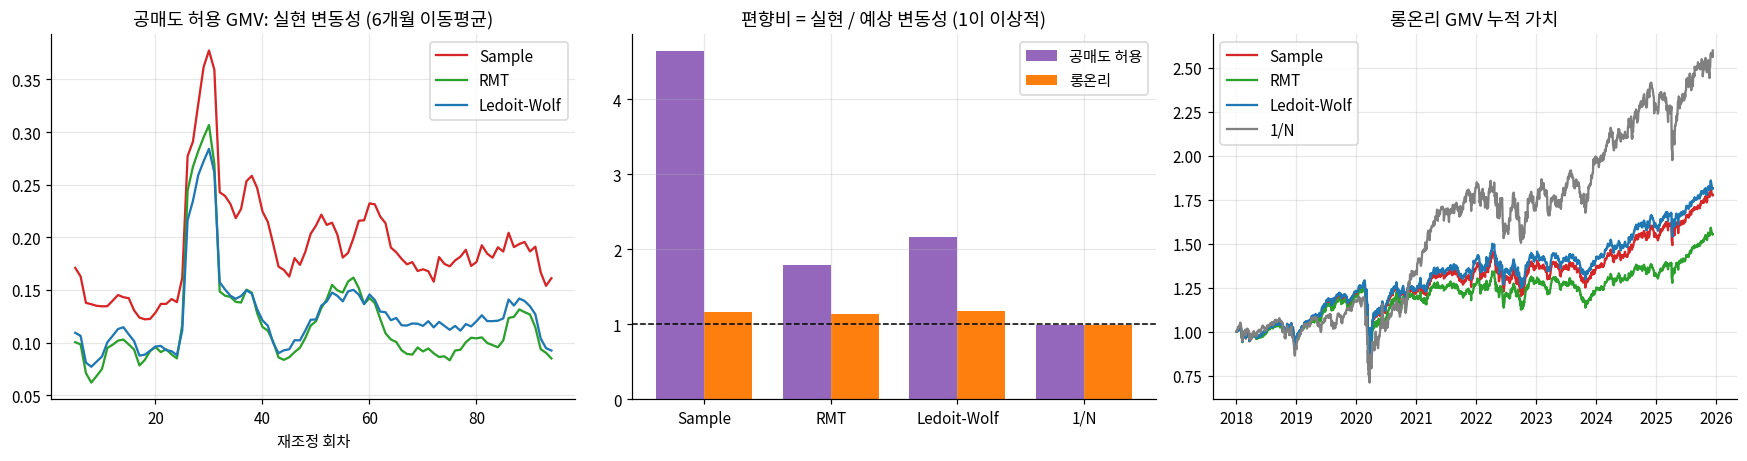

In [14]:
dates = ret.index[L:L + len(list(starts)) * H]
cols = {"Sample": "tab:red", "RMT": "tab:green", "Ledoit-Wolf": "tab:blue", "1/N": "grey"}

fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
for k in ["Sample", "RMT", "Ledoit-Wolf"]:
    ax[0].plot(pd.Series(np.array(res_ls[k]["real"]) * np.sqrt(252)).rolling(6).mean().values, c=cols[k], label=k)
ax[0].set(title="공매도 허용 GMV: 실현 변동성 (6개월 이동평균)", xlabel="재조정 회차"); ax[0].legend()

x = np.arange(4); b = 0.38
ax[1].bar(x - b/2, tab_ls["편향비"], b, label="공매도 허용", color="tab:purple")
ax[1].bar(x + b/2, tab_lo["편향비"], b, label="롱온리", color="tab:orange")
ax[1].axhline(1, c="k", ls="--", lw=1); ax[1].set_xticks(x, tab_ls.index)
ax[1].set(title="편향비 = 실현 / 예상 변동성 (1이 이상적)"); ax[1].legend()

for k in cols:
    ax[2].plot(dates, np.cumprod(1 + np.concatenate(res_lo[k]["r"])), c=cols[k], label=k)
ax[2].set(title="롱온리 GMV 누적 가치"); ax[2].legend()
plt.tight_layout(); plt.show()

## 7. 해석

아래 수치는 예시 실행(2016–2025, 결측 제외 후 N=364) 결과입니다. 종목 수가 달라지면 값도 조금씩 달라집니다.

**① 신호는 소수, 나머지는 잡음이다.** in-sample 364개 고유값 가운데 MP 상한($\lambda_+\approx1.37$)을 넘는 것은 24개뿐이고, 1번(시장 팩터) 하나가 전체 분산의 약 42%를 설명합니다. 2번 이후 신호 고유벡터는 섹터 대비로 해석됩니다.

**② 표본 공분산은 위험을 체계적으로 과소평가한다.** $q=L/N\approx1.4$에서 표본 공분산의 조건수는 약 8만입니다. 최적화기는 가장 작은 고유값 방향, 즉 "가짜로 안전한" 방향에 큰 비중을 싣습니다. 공매도 허용 GMV에서 Sample은 **예상 변동성 4.2%, 실현 변동성 20.9%**로 편향비가 4.6이었습니다. 총 노출 15배, 월 회전율 약 400%로 레버리지를 크게 쓰고도 실현 변동성은 1/N(20.8%)과 같았습니다. Michaud가 말한 **오차 극대화기(error maximizer)**의 전형입니다.

**③ RMT 필터와 Ledoit–Wolf가 이 문제를 크게 줄인다.** RMT는 실현 변동성 14.6%, 편향비 1.8, 총 노출 4.8배, 회전율 48%로 네 지표가 모두 크게 개선되었습니다. Ledoit–Wolf도 실현 변동성은 같았고, 편향비·회전율은 RMT가 더 좋았습니다. RMT는 **팩터 구조를 명시적으로 보존**한다는 해석상의 장점도 있습니다. 다만 편향비가 여전히 1보다 커서, 평탄화만으로는 과소평가가 완전히 사라지지 않습니다. 비선형 수축이나 팩터모형을 쓰는 이유입니다.

**④ 제약이 있으면 차이가 사라진다.** 롱온리 GMV에서는 세 추정량의 실현 변동성이 15.2~15.4%로 거의 같았습니다. 공매도 금지 제약 자체가 공분산 수축과 같은 효과를 내기 때문입니다(Jagannathan & Ma, 2003). 원본 노트북의 L1 페널티(γ=0.003)도 같은 역할을 합니다. 5절에서 두 해가 모두 6~7종목, 총 노출 1.0으로 사실상 롱온리 해가 된 것이 그 증거입니다.

**정리하면**, 원본의 "필터링해도 최적화 결과가 별로 바뀌지 않는다"는 결론은 강한 규제를 건 in-sample 비교에서만 성립합니다. 공매도를 허용하고 $N/T$가 큰 실무 상황을 out-of-sample로 평가하면 공분산 필터링의 효과가 뚜렷합니다. 반대로 롱온리 운용이라면 필터링에서 얻을 것이 크지 않습니다.

## 8. 더 해볼 것

1. 추정 창 $L$을 252, 1008로 바꿔 $q$에 따라 Sample과 RMT의 격차가 어떻게 변하는지 보기
2. `adjust_sigma=False`(원본 방식)와 비교하기 — 신호 고유값 개수와 OOS 성과 차이
3. 5절에서 γ를 0.0003, 0.03으로 바꿔 in-sample 투자선의 차이 관찰
4. 평탄화 대신 비선형 수축(Ledoit–Wolf 2020), 또는 신호 고유값만 남기는 팩터모형 공분산과 비교

## 참고문헌

- Marchenko, V. A., & Pastur, L. A. (1967). Distribution of eigenvalues for some sets of random matrices. *Mat. Sb.*, 72(114), 507–536.
- Laloux, L., Cizeau, P., Potters, M., & Bouchaud, J.-P. (2000). Random matrix theory and financial correlations. *IJTAF*, 3(3), 391–397.
- Bouchaud, J.-P., & Potters, M. (2009). Financial applications of random matrix theory: a short review. arXiv:0910.1205.
- Ledoit, O., & Wolf, M. (2004). A well-conditioned estimator for large-dimensional covariance matrices. *JMVA*, 88(2), 365–411.
- Jagannathan, R., & Ma, T. (2003). Risk reduction in large portfolios: Why imposing the wrong constraints helps. *JF*, 58(4), 1651–1683.
- Michaud, R. O. (1989). The Markowitz optimization enigma: Is 'optimized' optimal? *FAJ*, 45(1), 31–42.